In [1]:
# 2459 lines, 39 solved, 12 passed_some_traininputs, 8 passed_all_traininputs
from inductive_core_knowledge import * 

In [2]:
def print_arrays(case_num):
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'training'
tt = load_set(training_path)
known = load_serialized('assets/solved_indices_for_the_day.pkl')

1
[<function apply_scenarios at 0x7f6573ad01f0>]


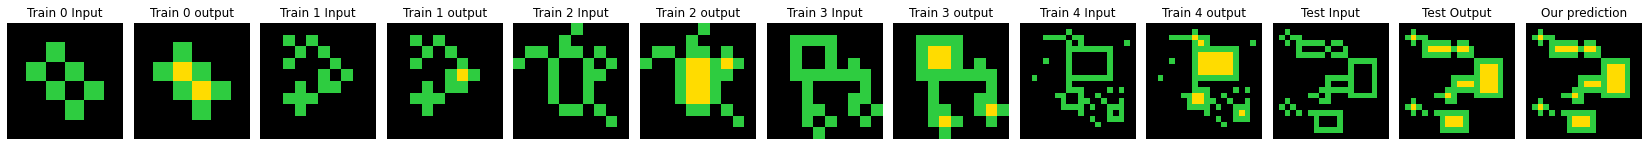

====
15
[<function apply_value_maps at 0x7f6573ad0160>]


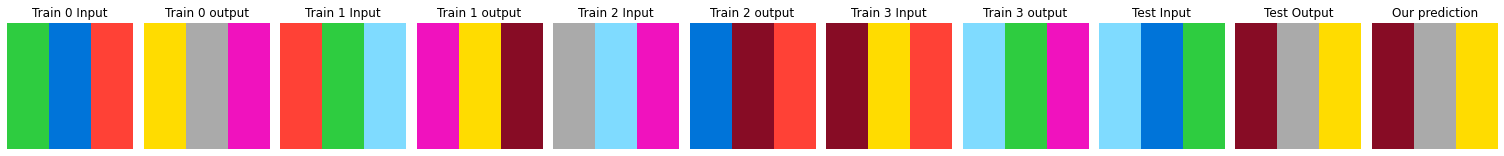

====


/home/hshallal/Desktop/ARCsolver/utils.py:496: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  target_indices = (np.argwhere(in_ == x[0]), np.argwhere(out_ == x[1]))


54
[<function apply_scenarios at 0x7f6573ad01f0>]


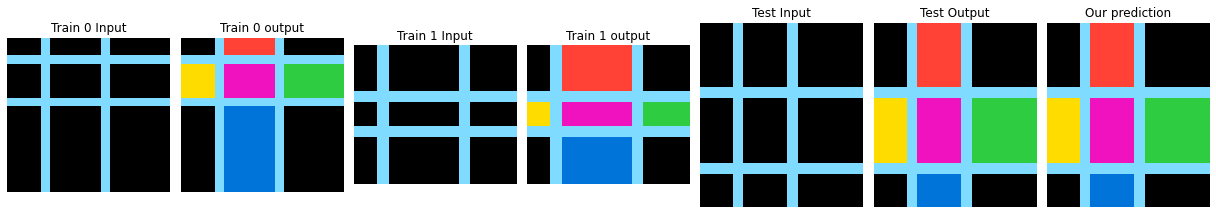

====
72
[<function apply_scenarios at 0x7f6573ad01f0>]


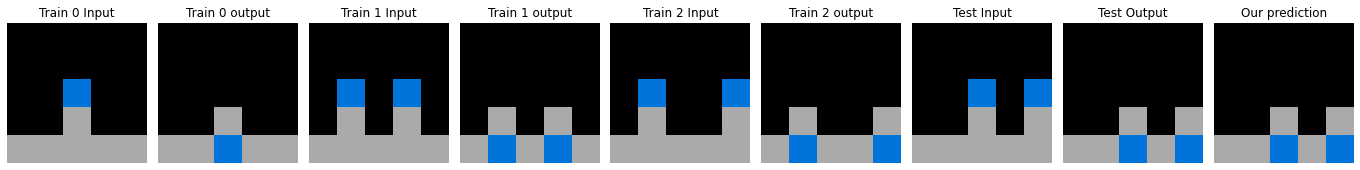

====
86
[<function screen_flips_rotation at 0x7f6573ce58b0>]


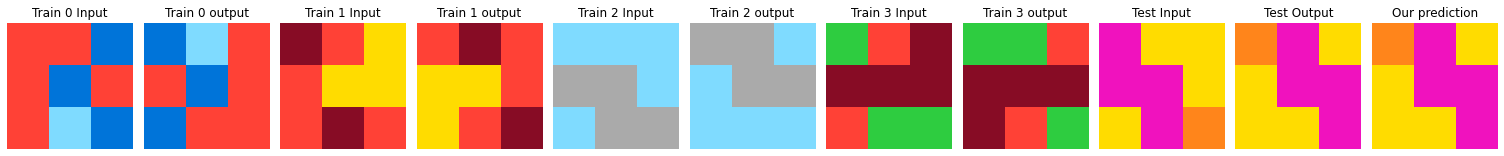

====
94
[<function apply_scenarios at 0x7f6573ad01f0>]


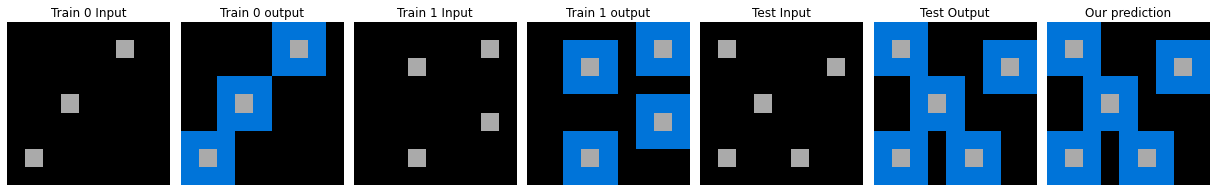

====
96
[<function apply_scenarios at 0x7f6573ad01f0>]


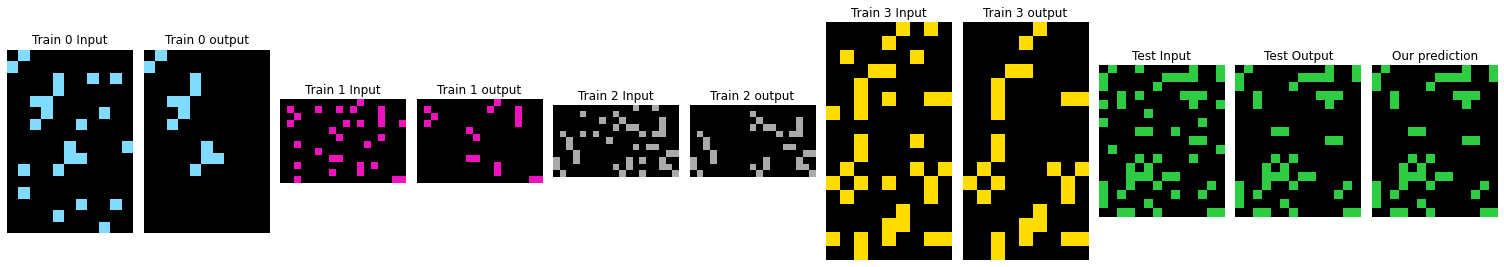

====
97
[<function apply_scenarios at 0x7f6573ad01f0>]


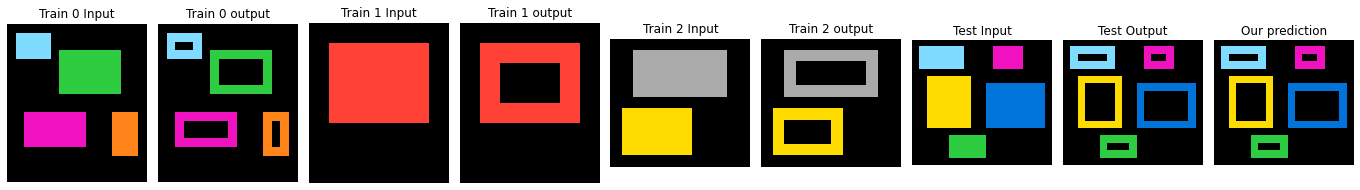

====
99
[<function apply_scenarios at 0x7f6573ad01f0>]


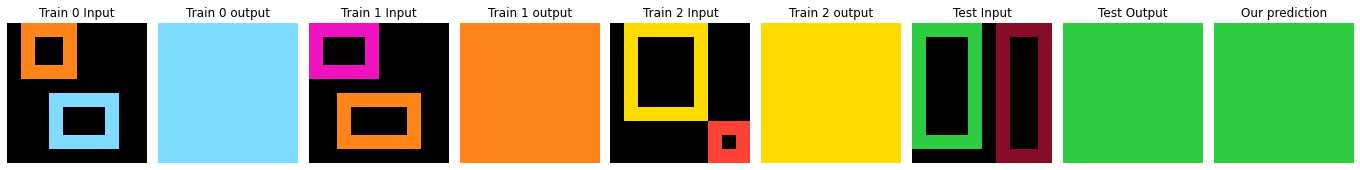

====
119
[<function apply_scenarios at 0x7f6573ad01f0>]


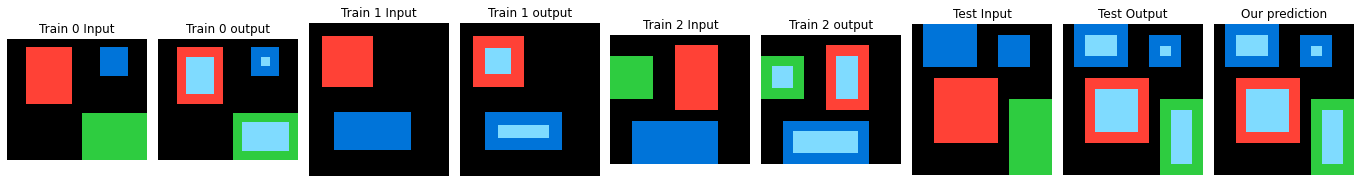

====
128
[<function apply_scenarios at 0x7f6573ad01f0>]


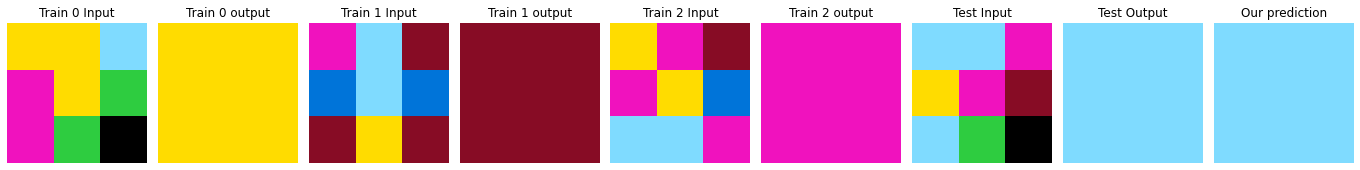

====
139
[<function screen_flips_rotation at 0x7f6573ce58b0>]


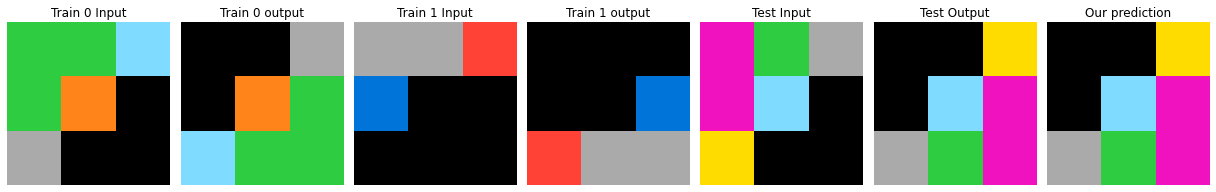

====
149
[<function screen_flips_rotation at 0x7f6573ce58b0>]


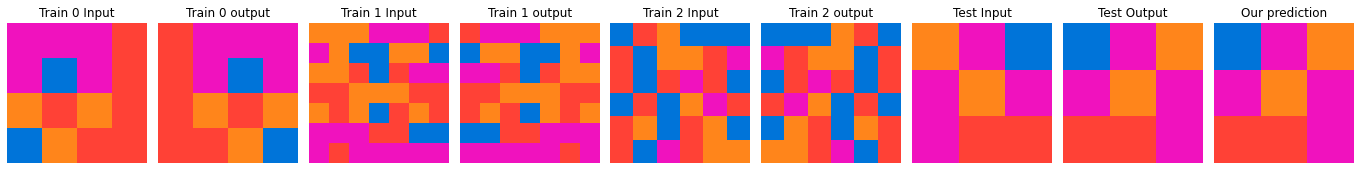

====
150
[<function apply_scenarios at 0x7f6573ad01f0>]


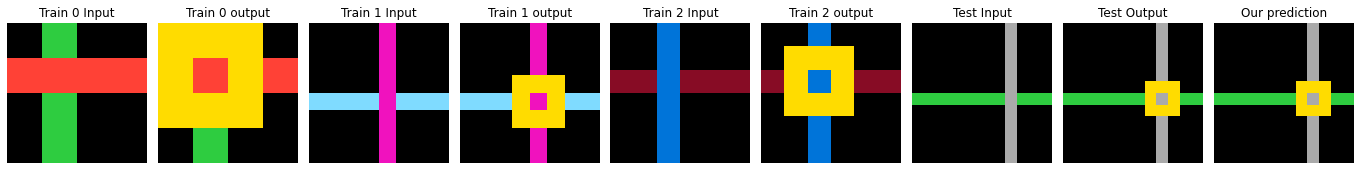

====
154
[<function screen_flips_rotation at 0x7f6573ce58b0>]


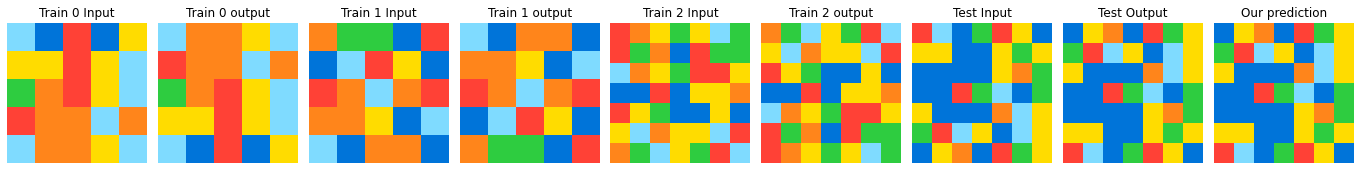

====
170
[<function apply_scenarios at 0x7f6573ad01f0>]


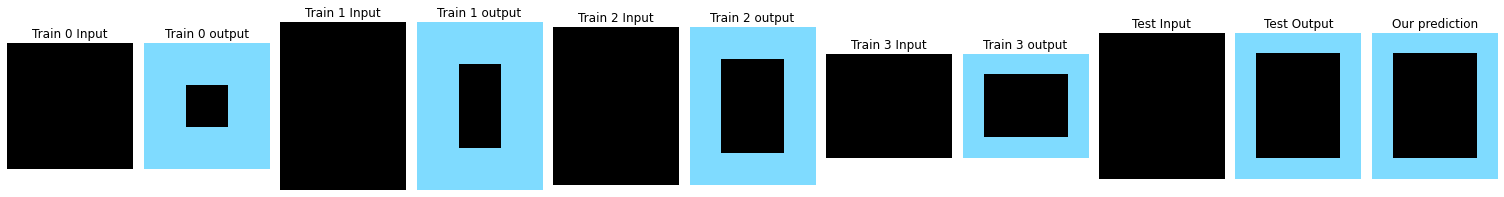

====
178
[<function screen_flips_rotation at 0x7f6573ce58b0>]


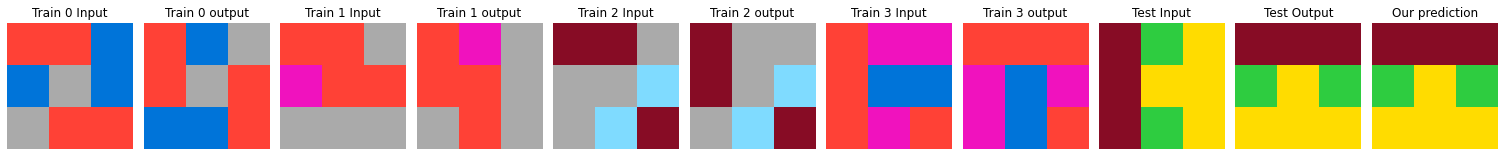

====
186
[<function apply_scenarios at 0x7f6573ad01f0>]


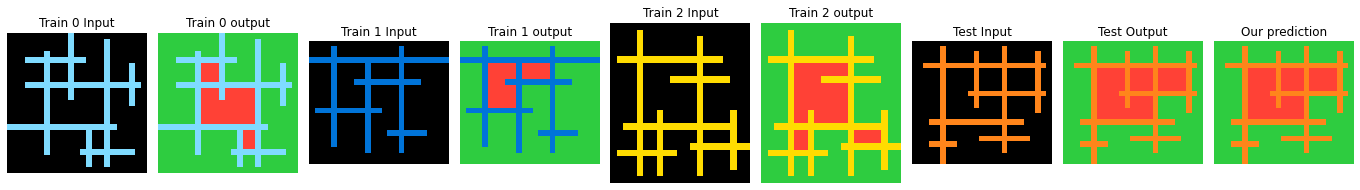

====
222
[['is_exp_cont', [3.0, 3.0]]]


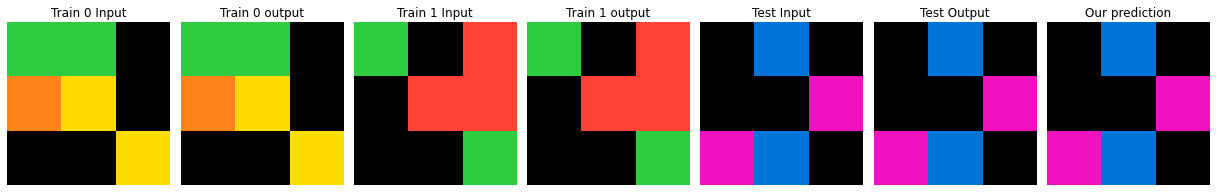

====
240
[<function screen_flips_rotation at 0x7f6573ce58b0>]


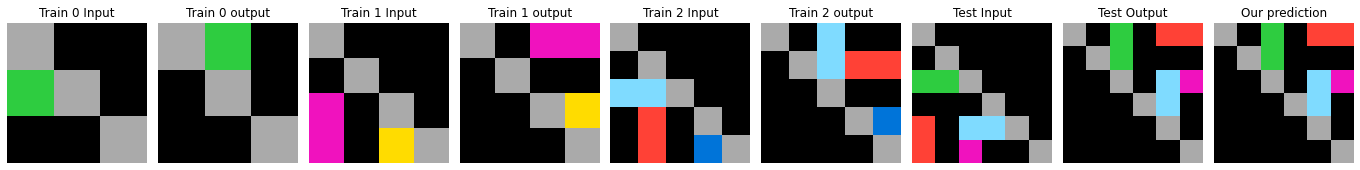

====
250
[<function apply_scenarios at 0x7f6573ad01f0>]


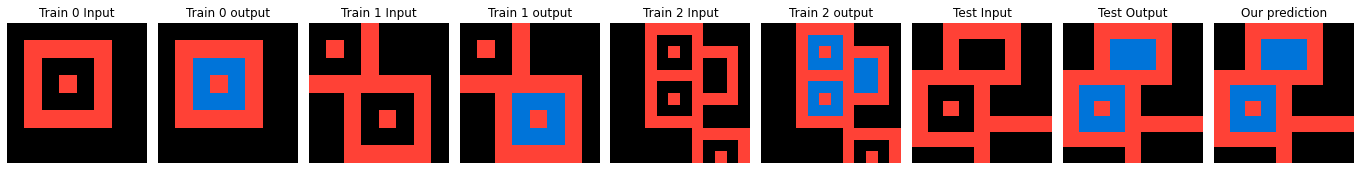

====
257
[<function apply_scenarios at 0x7f6573ad01f0>]


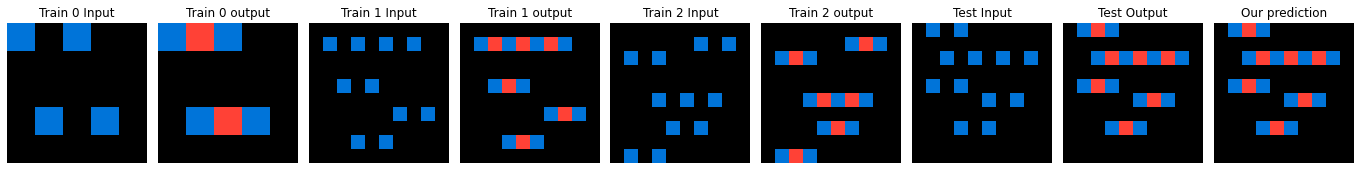

====
266
[<function apply_scenarios at 0x7f6573ad01f0>]


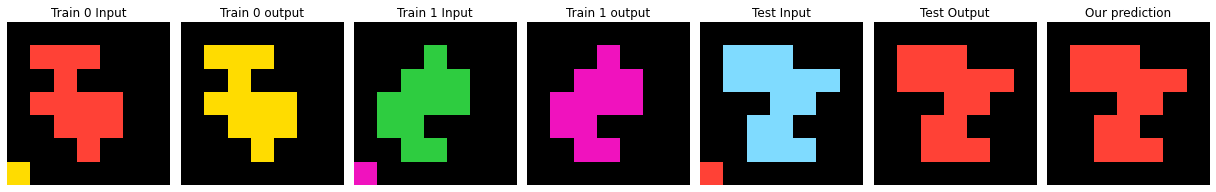

====
268
[['is_exp_cont_freq_unique_nonbg', [2.0, 3.0, 5.0]]]


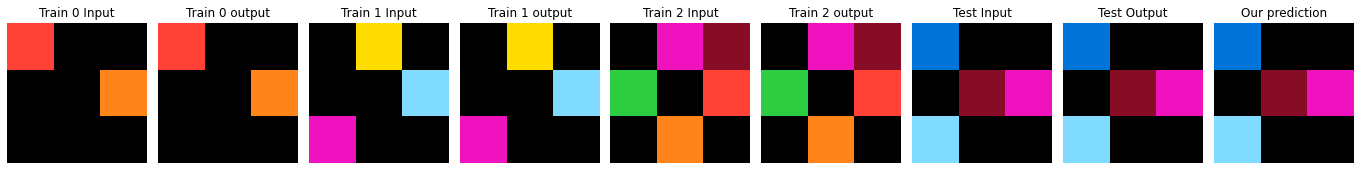

====
275
[<function apply_value_maps at 0x7f6573ad0160>]


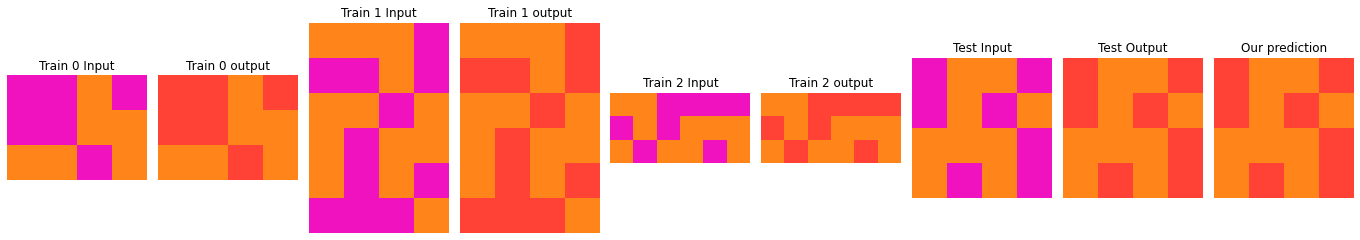

====
282
[<function apply_scenarios at 0x7f6573ad01f0>]


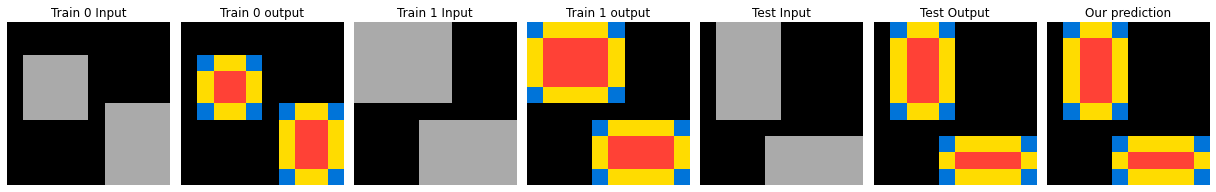

====
288
[['is_exp_cont_freq_unique_nonbg', [2.0, 2.0, 3.0, 3.0, 4.0]]]


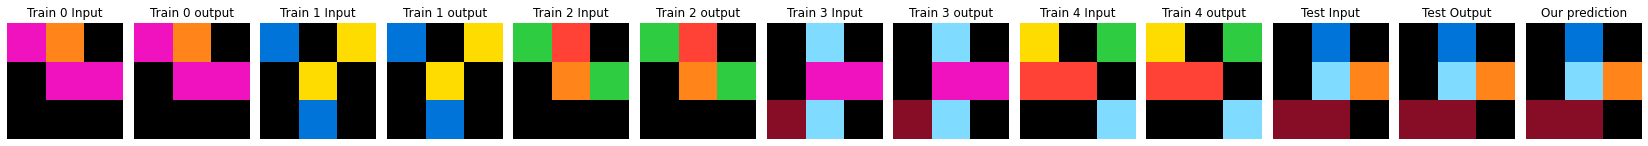

====
293
[<function apply_scenarios at 0x7f6573ad01f0>]


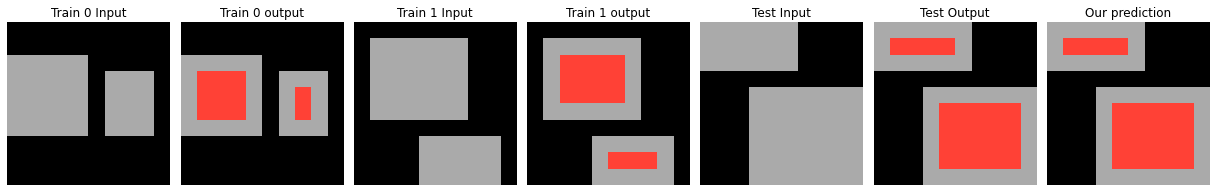

====
306
[['is_exp_cont', [2.0, 2.0]]]


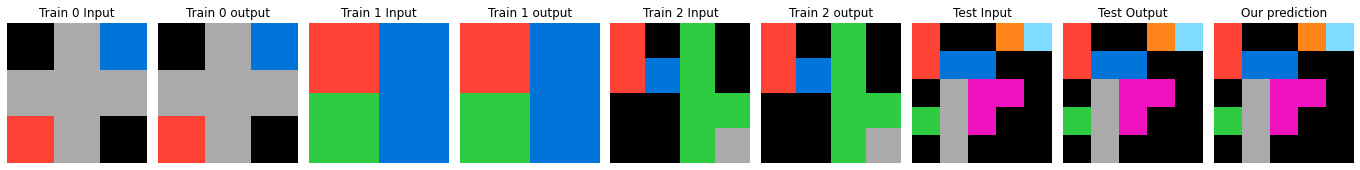

====
308
[<function apply_value_maps at 0x7f6573ad0160>]


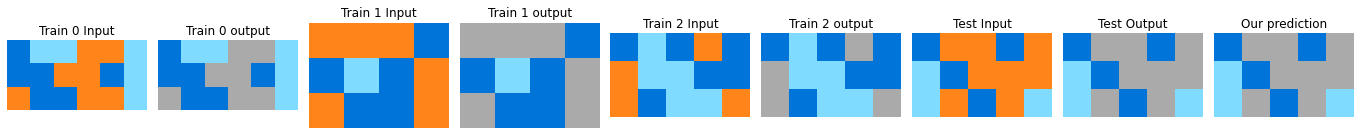

====
316
[<function apply_scenarios at 0x7f6573ad01f0>]


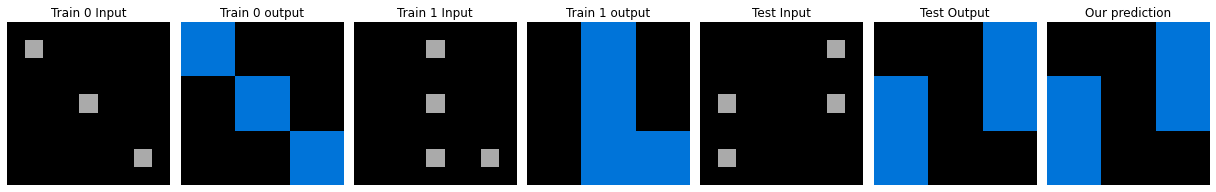

====
330
[<function apply_scenarios at 0x7f6573ad01f0>]


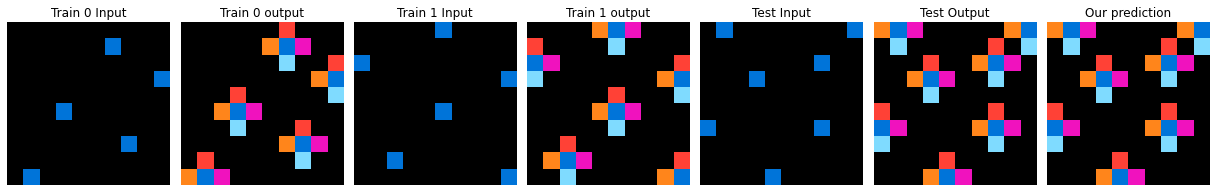

====
336
[<function apply_scenarios at 0x7f6573ad01f0>]


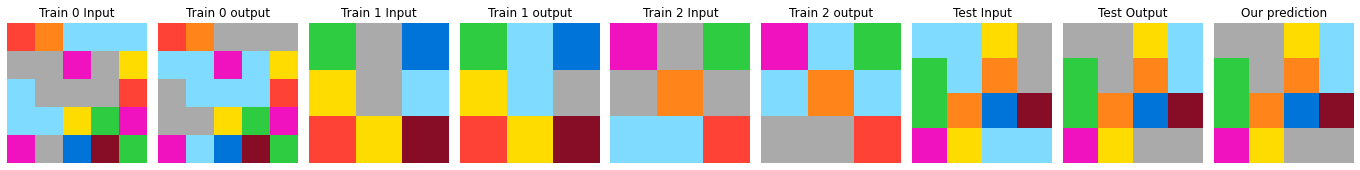

====
337
[<function apply_scenarios at 0x7f6573ad01f0>]


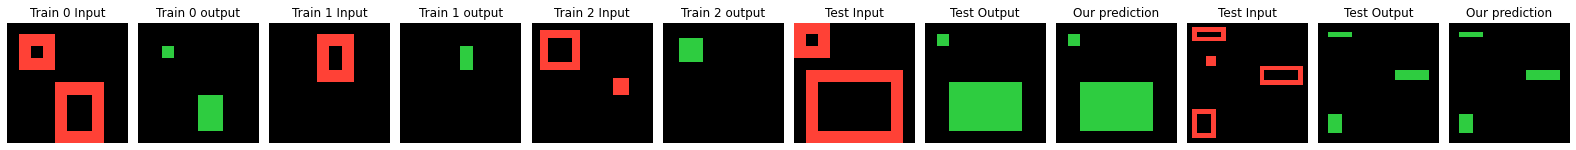

====
338
[<function apply_scenarios at 0x7f6573ad01f0>]


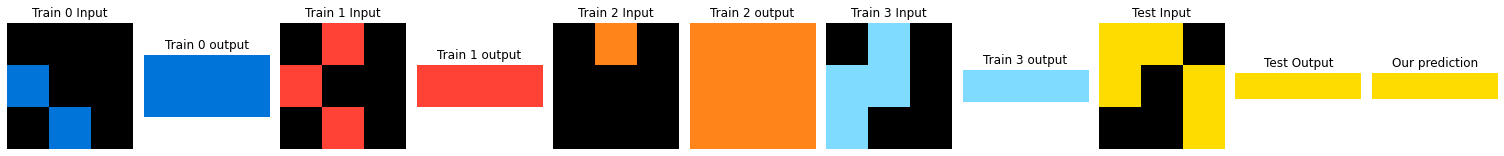

====
345
[<function apply_scenarios at 0x7f6573ad01f0>]


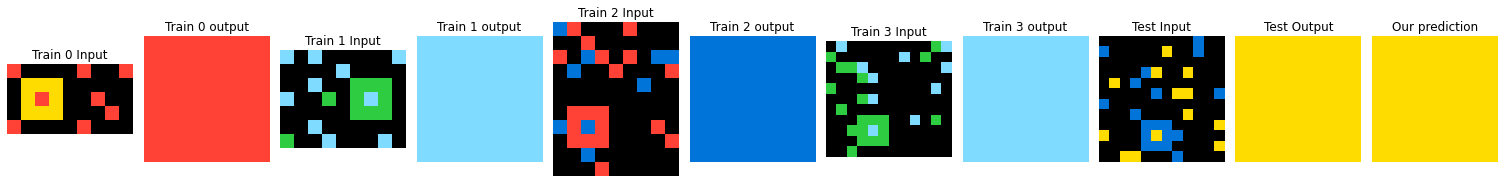

====
372
[<function apply_scenarios at 0x7f6573ad01f0>]


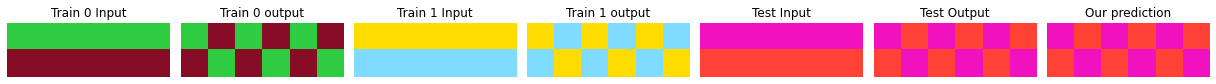

====
379
[<function screen_flips_rotation at 0x7f6573ce58b0>]


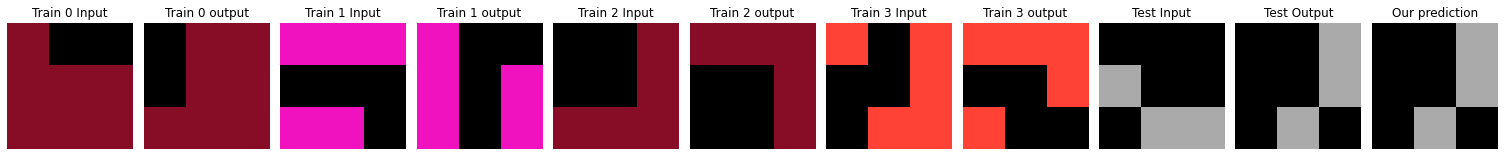

====
388
[<function apply_scenarios at 0x7f6573ad01f0>]


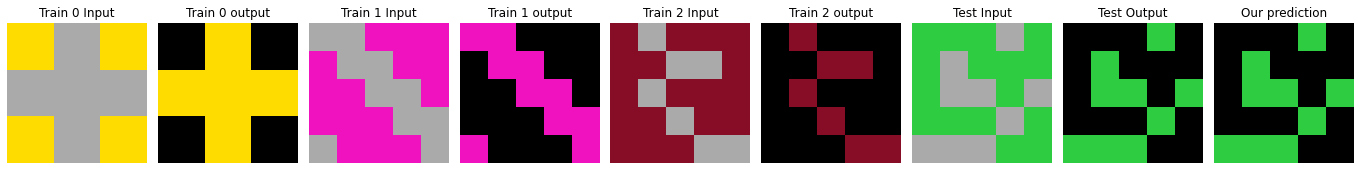

====
It took this number of seconds:  1841.3436731300026
400


In [4]:
from timeit import default_timer as timer
start = timer()
today_analysis = []
for n in range(len(tt)):
    this_task = Inductive(tt[n])
    today_analysis.append(this_task)
    if this_task.solved == 'solved':
        print(n)
        print(this_task.mechanisms)
        plot_task_eval(tt[n], [x.astype('int64') for x in this_task.test_situation])
        print('====')
    

serialize(today_analysis, 'assets/today_analysis')
end = timer()
print("It took this number of seconds: ", end - start)
print(len(today_analysis))
# It took this number of seconds: 1015

In [5]:
previous_analysis = load_serialized('assets/today_analysis')
#previous_screening_results = load_serialized('assets/screening_results')

In [6]:
for n in known:
    if previous_analysis[n].solved != 'solved':
        print(n)
        plot_task(tt[n])
        print('====')

In [7]:
current_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.dimension_status == 'deduced' and this_task.solved != 'solved':
        current_attention.append(n)
        
print(len(current_attention))

60


In [8]:
coding_situation = {}
coding_situation[-1] = []
coding_situation[0] = []
coding_situation[1] = []


for n in range(len(previous_analysis)):
    this_task = previous_analysis[n]
    if this_task.objective_status == 'irr':
        coding_situation[-1].append(n)
    elif this_task.objective_status == 'obd':
        coding_situation[0].append(n)
    elif this_task.objective_status == 'red':
        coding_situation[1].append(n)

        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))



def screen_all(previous_analysis):
    results = deepcopy(results_dict)
    
    for task in range(len(previous_analysis)):
        #print(task)
        this_task = deepcopy(previous_analysis[task])
        current_situation, train_situation, train_screen, test_situation, test_screen = this_task.current_situation, this_task.train_situation, this_task.train_screen, this_task.test_situation, this_task.test_screen
        
        if current_situation in results_dict.keys():
            results[current_situation].append(task)
        else:
            results['unknown'].append((task, current_situation))

    for k, v in results.items():
        print(k, ' : ', len(v))
    
    return results

screening_results = screen_all(previous_analysis)
# print(this_task.apply_routine_list)

serialize(screening_results, 'assets/screening_results')

all_undeduced = 0
for n in previous_analysis:
    if n.dimension_status != 'deduced':
        all_undeduced += 1
all_undeduced

# training: 310 deduces: 0.775
# -1  :  64 # irr
# 0  :  245 # obd
# 1  :  91 # red 


-1  :  64
0  :  245
1  :  91
ineligible  :  361
passed_all_traininputs  :  0
passed_some_traininputs  :  0
unpassed_all_traininputs  :  0
passed_all_testinputs  :  39
passed_some_testinputs  :  0
unpassed_all_testinputs  :  0
unknown  :  0


95

In [9]:
# print(this_task.apply_routine_list)
screening_results = {}
solved = 0
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.solved == 'solved':
        solved += 1
    overall = [x[2] for x in this_task.apply_routine_list]
    imp = [x for x in overall if x != 'ineligible']
    for m in overall:
        if m != 'ineligible':
            if m not in screening_results.keys():
                screening_results[m] = []
            screening_results[m].append(n)

for k, v in screening_results.items():
    print(k, ' : ', len(v))
    
print(solved)

# passed_all_testinputs  :  32
# passed_some_traininputs  :  11
# unpassed_all_testinputs  :  8
# 36


passed_all_testinputs  :  35
passed_some_traininputs  :  12
unpassed_all_testinputs  :  8
39


80


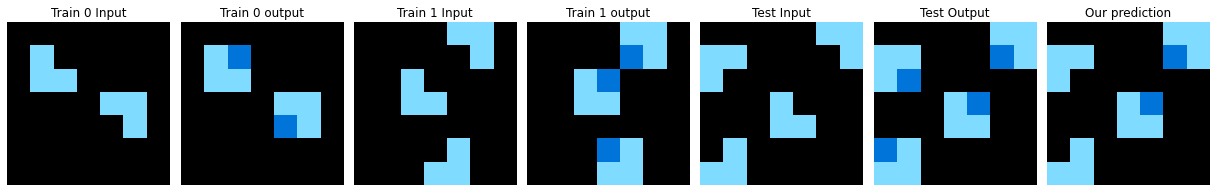

global_objective: [[('bg', 'bg'), ('bg', 'nonbg0pr'), [8], (8, {131, 136, 13, 14, 152, 39, 173, 46, 49, 187, 59, 61, 72, 206, 207, 78, 211, 85, 221, 222, 95, 248, 226, 227, 229, 105, 234, 236, 238, 244, 245, 118, 247, 120, 246, 250, 251, 252, 253, 255}, {200, 204, 166})]]
pr_kn_apply_scenarios: [['bg', 8, [166, 200, 204], 'nonbg0pr']]
142


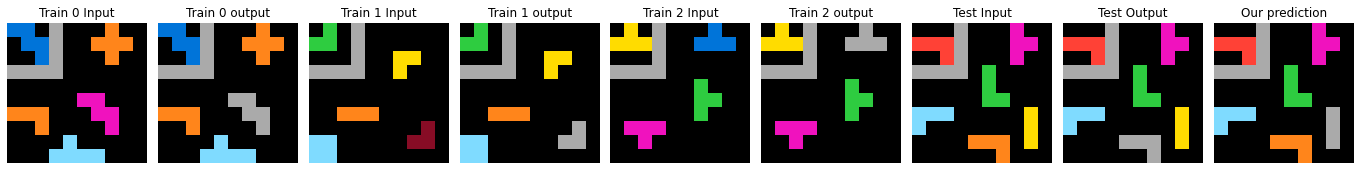

global_objective: [[('nonbg1', 'nonbg0pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg1', 'direct', 'nonbg0pr']]
166


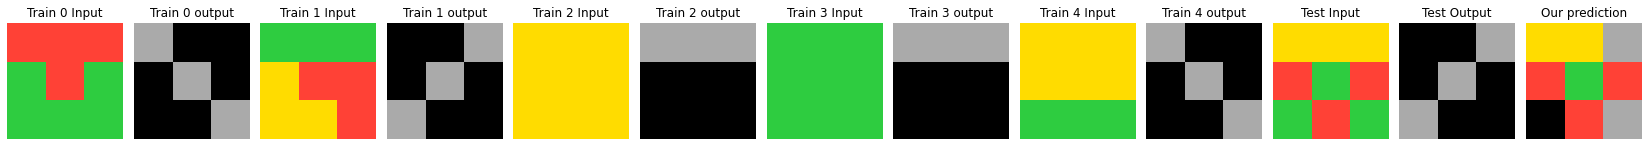

global_objective: [[('nonbg1', 'nonbg-1pr'), ('nonbg1', 'nonbg0pr'), [14], (14, {162, 226, 100, 270, 47, 83, 54, 55, 151, 188, 152, 222}, {64, 483, 357, 74, 202, 57, 61})], [('nonbg2', 'nonbg-1pr'), ('nonbg2', 'nonbg0pr'), [7, 8, 9, 12, 14, 15], (7, {129, 226, 36, 232, 108, 187, 49, 27}, {586, 59, 68, 70}), (8, {4, 39, 110, 15, 49, 17, 85, 187}, {59, 28, 29, 207}), (9, {1, 4, 6, 8, 15, 49, 187, 28}, {59, 5, 86, 7}), (12, {129, 227, 37, 233, 109, 50, 27, 188}, {587, 60, 69, 70}), (14, {32, 198, 237, 239, 143, 49, 245, 119, 121, 60}, {81, 84, 597, 70}), (15, {132, 228, 38, 234, 110, 50, 188, 30}, {72, 60, 70, 588})], [('nonbg3', 'nonbg-1pr'), ('nonbg3', 'nonbg0pr'), [5, 7, 8, 9, 10, 12, 13, 14, 15], (5, {9, 13}, {8}), (7, {114, 147}, {36}), (8, {39, 15}, {17}), (9, {18, 3}, {1}), (10, {9, 13}, {8}), (12, {114, 147}, {36}), (13, {16, 11}, {10}), (14, {160, 123}, {44}), (15, {116, 150}, {38})]]
pr_kn_apply_scenarios: [['nonbg1', 14, [226, 162, 100, 270, 47, 83, 55, 54, 151, 152, 188, 222],

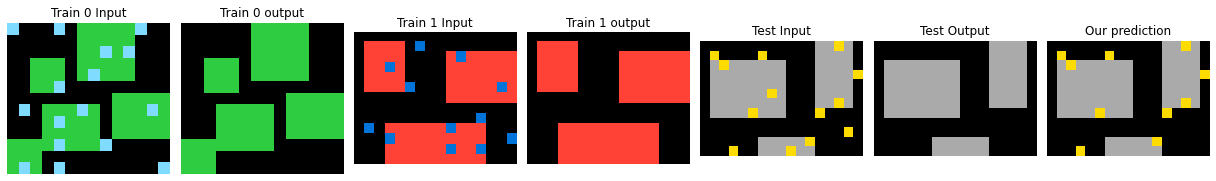

global_objective: [[('nonbg0', 'bg'), ('nonbg0', 'nonbg1'), [14], (14, {226, 515, 198, 70, 266, 525, 270, 463, 216, 157, 94}, {481, 485, 559, 593, 595, 211, 597, 539, 255})]]
pr_kn_apply_scenarios: [['nonbg0', 14, [226, 515, 70, 198, 266, 525, 270, 463, 216, 157, 94], 'bg'], ['nonbg0', 14, [481, 485, 559, 593, 595, 211, 597, 539, 255], 'nonbg1']]
228


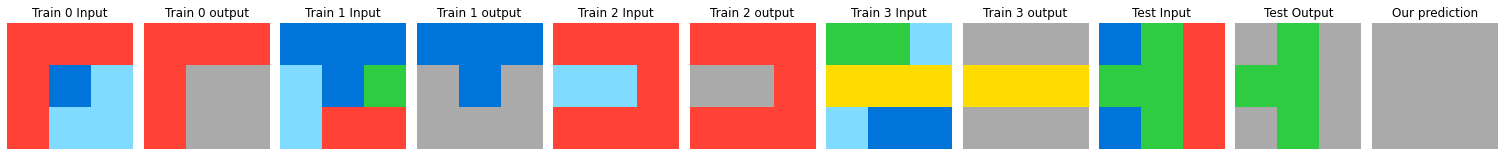

global_objective: [[('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')], [('nonbg2', 'nonbg-1pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg0', 'direct', 'nonbg-1pr'], ['nonbg1', 'direct', 'nonbg-1pr'], ['nonbg2', 'direct', 'nonbg-1pr']]
251


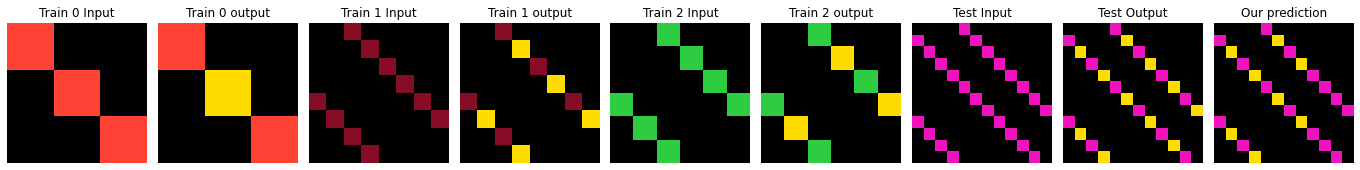

global_objective: [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]]
pr_kn_apply_scenarios: [['nonbg1', 3, [1, 3, 5, 7], 'nonbg0pr']]
271


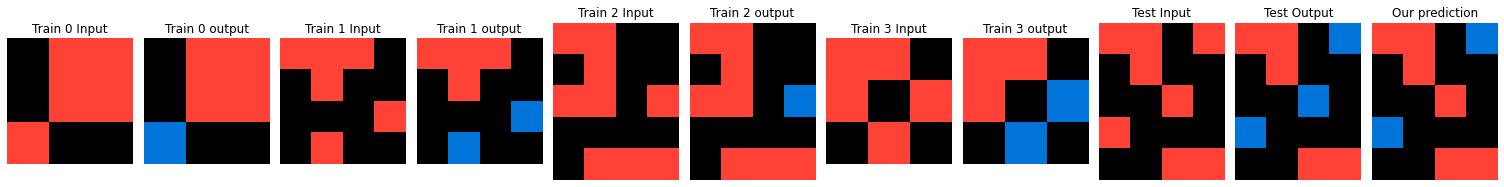

global_objective: [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg-1pr'), [7, 8, 9, 12, 13, 14, 15], (7, {448, 544, 34, 226, 486, 136, 202, 42, 268, 142, 238, 46, 49, 146, 114, 470, 150}, {36, 172, 207, 211, 158}), (8, {131, 134, 44, 13, 78, 187, 16, 48, 49, 19, 243, 85, 51, 124, 58, 59, 92}, {77, 207, 17, 211, 57}), (9, {2, 3, 4, 134, 7, 13, 14, 48, 49, 124, 20, 23, 24, 27, 28, 29}, {1, 9, 207, 211, 22}), (12, {544, 449, 35, 227, 486, 136, 202, 42, 268, 238, 143, 46, 146, 147, 50, 115, 470, 150}, {37, 173, 207, 211, 159}), (13, {4, 7, 8, 9, 17}, {16, 10, 3, 6}), (14, {147, 151, 152, 153, 283, 161, 39, 559, 47, 56, 57, 61, 455, 217, 485, 233, 501, 119, 253}, {226, 44, 176, 222, 159}), (15, {450, 546, 36, 228, 488, 138, 204, 44, 270, 144, 240, 48, 50, 148, 116, 472, 152}, {160, 38, 174, 208, 212})]]
pr_kn_apply_scenarios: [['nonbg0pr', 13, [16, 10, 3, 6], 'nonbg-1pr']]
291


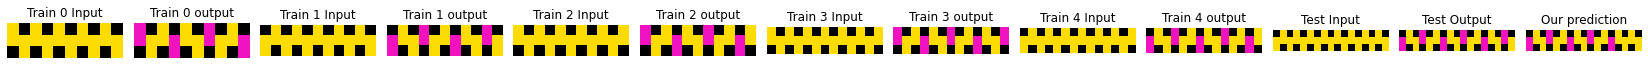

global_objective: [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]
pr_kn_apply_scenarios: [['bg', 3, [0, 3, 6, 9, 12], 'nonbg0pr']]


In [10]:
for n in screening_results['unpassed_all_testinputs']:
    print(n)
    plot_task_eval(tt[n], [x.astype('int64') for x in previous_analysis[n].test_situation])
    print('global_objective:', previous_analysis[n].global_objective)
    print('pr_kn_apply_scenarios:', previous_analysis[n].pr_kn_apply_scenarios)
    print('======')

51


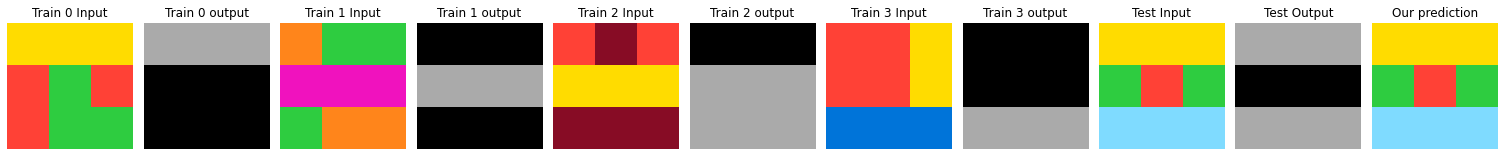

global_objective: [[('nonbg1', 'nonbg-1pr', 'direct')], [('nonbg2', 'nonbg-1pr', 'direct')], [('nonbg3', 'nonbg0pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg1', 'direct', 'nonbg-1pr'], ['nonbg2', 'direct', 'nonbg-1pr'], ['nonbg3', 'direct', 'nonbg0pr']]
68


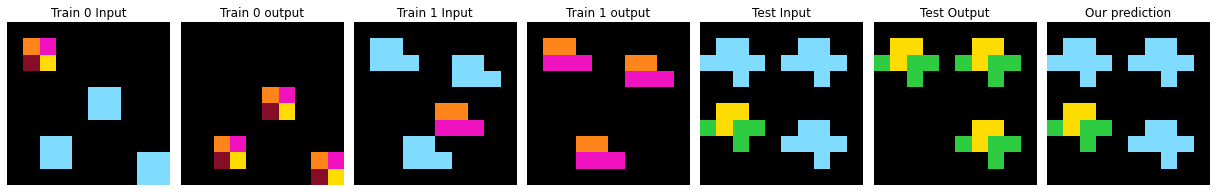

global_objective: [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg3', 'bg', 'direct')], [('nonbg4', 'bg', 'direct')], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg1pr'), [7, 8, 9, 12, 14, 15], (7, {130, 582, 500, 506, 478}, {448, 450, 543}), (8, {232, 200, 204, 144, 49}, {166, 118}), (9, {39, 144, 16, 18, 49}, {1, 59, 118}), (12, {480, 131, 584, 502, 507}, {545, 450, 451, 452}), (14, {515, 521, 493, 145, 597}, {465, 558, 463}), (15, {480, 132, 584, 502, 508}, {450, 452, 546})], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg3'), [7, 8, 9, 12, 14, 15], (7, {506, 130}, {548, 85}), (8, {49, 204}, {85, 189}), (9, {16, 49}, {85}), (12, {507, 131}, {549, 86}), (14, {521, 145}, {563, 94}), (15, {132, 508}, {86, 550})], [('nonbg2pr', 'nonbg0pr'), ('nonbg2pr', 'nonbg4'), [3, 7, 8, 9, 12, 14, 15], (3, {9, 3, 6}, {8, 2, 5}), (7, {506, 130}, {114, 478}), (8, {49, 204}, {200, 39}), (9, {16, 49}, {18, 39}), (12, {507, 131}, {115, 479}), (14, {521, 145}, {129, 493}), (15, {13

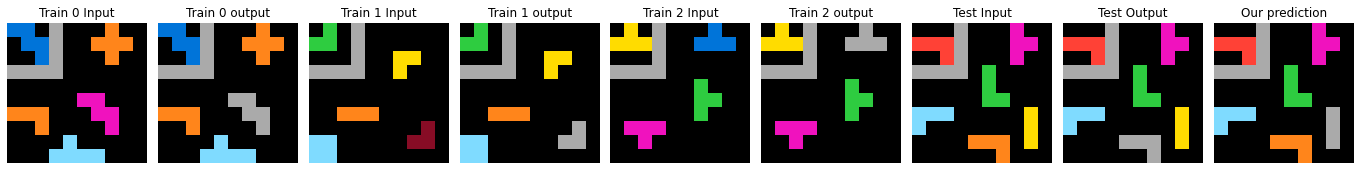

global_objective: [[('nonbg1', 'nonbg0pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg1', 'direct', 'nonbg0pr']]
202


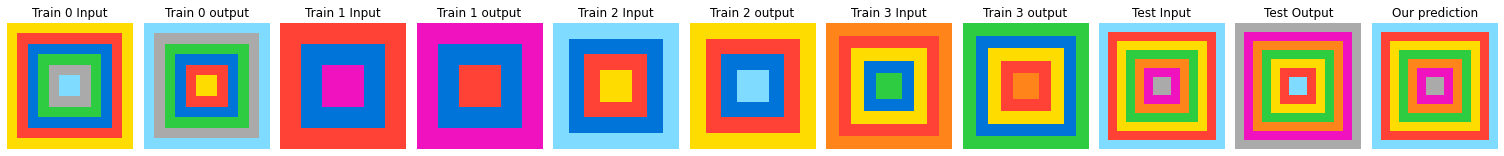

global_objective: [[('nonbg-1pr', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg1', 'nonbg4', 'direct')], [('nonbg2', 'nonbg0pr', 'direct')], [('nonbg3', 'nonbg-1pr', 'direct')], [('nonbg4', 'nonbg1', 'direct')]]
pr_kn_apply_scenarios: [['nonbg-1pr', 'direct', 'nonbg3'], ['nonbg0pr', 'direct', 'nonbg2'], ['nonbg1', 'direct', 'nonbg4'], ['nonbg2', 'direct', 'nonbg0pr'], ['nonbg3', 'direct', 'nonbg-1pr'], ['nonbg4', 'direct', 'nonbg1']]
221


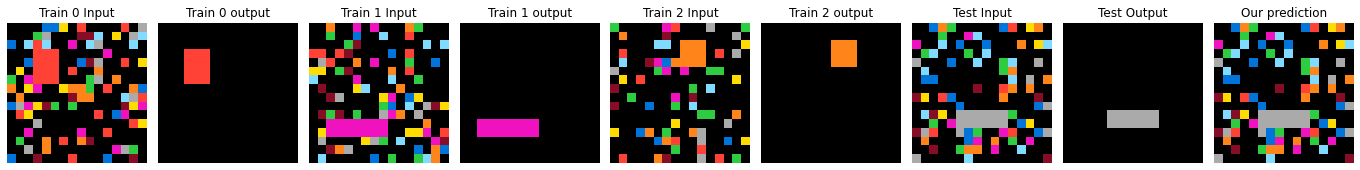

global_objective: [[('nonbg0pr', 'bg', 'direct')], [('nonbg2pr', 'bg', 'direct')], [('nonbg3pr', 'bg', 'direct')], [('nonbg4pr', 'bg', 'direct')], [('nonbg5pr', 'bg', 'direct')], [('nonbg6pr', 'bg', 'direct')], [('nonbg7pr', 'bg', 'direct')], [('nonbg8pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'bg'), [14], (14, {704, 772, 709, 584, 723, 436, 533, 668, 606, 255}, {320, 673, 194, 773, 203, 269, 141, 755, 221, 510})]]
pr_kn_apply_scenarios: [['nonbg0pr', 'direct', 'bg'], ['nonbg2pr', 'direct', 'bg'], ['nonbg3pr', 'direct', 'bg'], ['nonbg4pr', 'direct', 'bg'], ['nonbg5pr', 'direct', 'bg'], ['nonbg6pr', 'direct', 'bg'], ['nonbg7pr', 'direct', 'bg'], ['nonbg8pr', 'direct', 'bg'], ['nonbg1pr', 14, [320, 673, 194, 773, 203, 269, 141, 755, 221, 510], 'bg']]
228


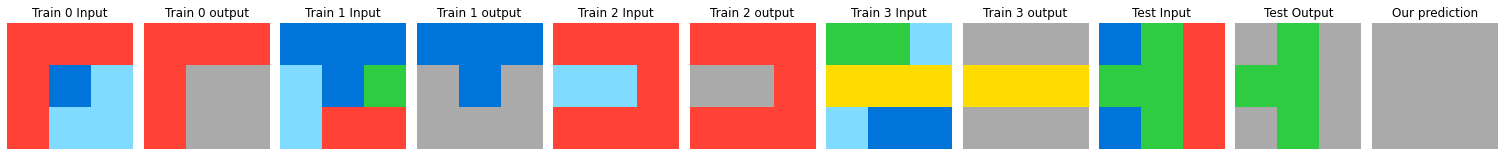

global_objective: [[('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')], [('nonbg2', 'nonbg-1pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg0', 'direct', 'nonbg-1pr'], ['nonbg1', 'direct', 'nonbg-1pr'], ['nonbg2', 'direct', 'nonbg-1pr']]
260


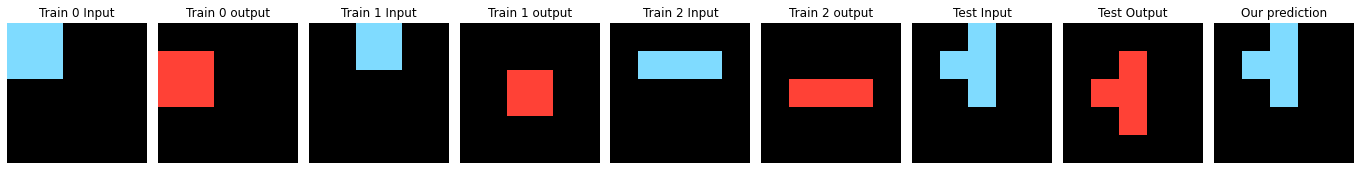

global_objective: [[('bg', 'bg'), ('bg', 'nonbg0pr'), [9], (9, {1, 3, 4, 5, 7, 8, 14, 15, 18, 20, 28, 39, 173, 49, 187, 207, 211, 85, 255}, {48, 16, 6, 31})], [('nonbg1pr', 'bg'), ('nonbg1pr', 'nonbg0pr'), [2, 7, 8, 9, 12, 14, 15], (2, {0}, {1}), (7, {136, 59}, {108, 548}), (8, {49, 59}, {189, 39}), (9, {19, 59}, {85, 15}), (12, {136, 59}, {108, 548}), (14, {64, 151}, {563, 123}), (15, {138, 60}, {550, 110})]]
pr_kn_apply_scenarios: [['bg', 9, [48, 16, 6, 31], 'nonbg0pr'], ['nonbg1pr', 2, [0], 'bg'], ['nonbg1pr', 2, [1], 'nonbg0pr']]
292


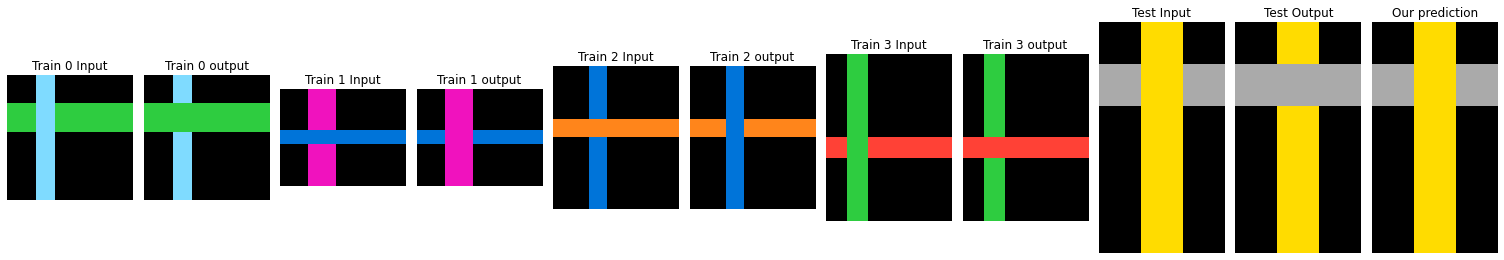

global_objective: [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [5, 10, 13, 14], (5, {5, 7, 8, 9, 12, 14}, {0}), (10, {5, 7, 8, 9, 12, 14}, {0}), (13, {7, 8, 9, 10, 11, 12, 14, 15, 16, 17}, {2, 3}), (14, {225, 514, 122, 584, 521, 589, 143, 272, 591, 529, 721, 532, 602, 246, 151, 474, 702}, {576, 582, 714, 524, 462, 597, 693, 507})]]
pr_kn_apply_scenarios: [['nonbg1', 'direct', 'nonbg1'], ['nonbg0', 5, [0], 10, [0], 'nonbg1']]
297


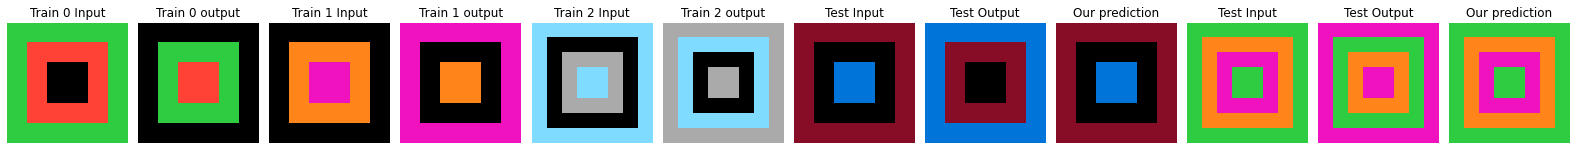

global_objective: [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg-1pr', 'direct', 'nonbg0'], ['nonbg0', 'direct', 'nonbg1'], ['nonbg1', 'direct', 'nonbg-1pr']]
328


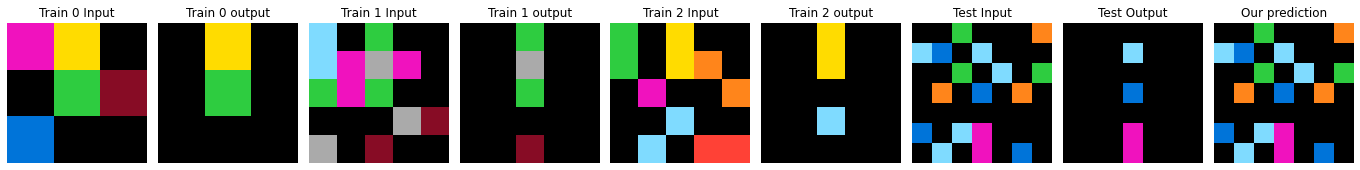

global_objective: [[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [3, 5, 7, 8, 9, 10, 12, 13, 14, 15], (3, {2}, {0}), (5, {15, 7}, {8}), (7, {138, 435}, {132}), (8, {24, 83}, {15}), (9, {2, 10}, {6}), (10, {8, 16}, {9}), (12, {139, 436}, {133}), (13, {10, 18}, {11}), (14, {145, 450}, {140}), (15, {141, 438}, {135})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [2, 3, 5, 7, 8, 9, 10, 12, 13, 14, 15], (2, {4}, {3}), (3, {2}, {4}), (5, {13}, {14}), (7, {296}, {232}), (8, {147}, {109}), (9, {1}, {7}), (10, {13}, {14}), (12, {296}, {232}), (13, {15}, {16}), (14, {309}, {246}), (15, {298}, {234})], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [3, 5, 7, 8, 9, 10, 12, 13, 14, 15], (3, {2}, {0, 1, 3}), (5, {0, 13}, {8, 15}), (7, {772, 429}, {296, 699, 39}), (8, {176, 42}, {194, 147, 39}), (9, {26, 4}, {1, 5, 39}), (10, {1, 14}, {16, 9}), (12, {773, 430}, {40, 297, 700}), (13, {17, 3}, {9, 10, 18}), (14, {785, 429}, {304, 714, 47}), (15, {77

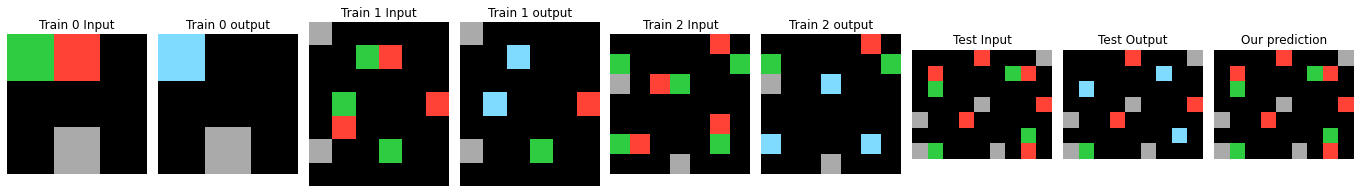

global_objective: [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg0pr', 'direct', 'bg'], ['nonbg1pr', 'direct', 'nonbg2pr']]
343


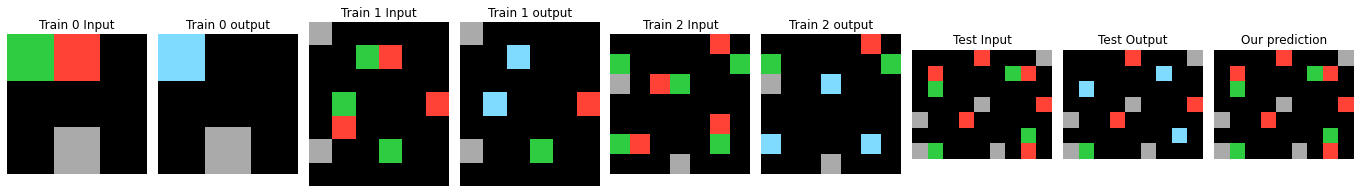

global_objective: [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]]
pr_kn_apply_scenarios: [['nonbg0pr', 'direct', 'bg'], ['nonbg1pr', 'direct', 'nonbg2pr']]


In [11]:
for n in screening_results['passed_some_traininputs']:
    print(n)
    plot_task_eval(tt[n], [x.astype('int64') for x in previous_analysis[n].test_situation])
    print('global_objective:', previous_analysis[n].global_objective)
    print('pr_kn_apply_scenarios:', previous_analysis[n].pr_kn_apply_scenarios)
    print('======')

In [ ]:
def demonstrate_heuristic_candidacy(n):
    print(n)
    plot_task(tt[n])
    this_task = previous_analysis[n]
    print('Situation: ', [x[2] for x in this_task.apply_routine_list])
    print(this_task.objective_status, this_task.running_objective, this_task.global_objective)
    print(this_task.train_screen, this_task.test_screen)
    print(this_task.token_to_colors, this_task.test_token_to_colors, )
    print(this_task.pr_kn_apply_scenarios)
    print('=====')

In [ ]:
# case 343: the global objective didn't pick up on the other more elaborate objectives
# [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2, 3, 6], (2, {3}, {1, 4}), (3, {5}, {1, 3}), (6, {1}, {2, 3})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [2, 3, 6], (2, {5}, {1, 3}), (3, {3}, {1, 2}), (6, {1}, {2})]]
# case 228: tokenization of test didn't spare an int anchor which is be default
# is the one spared of tokenization, in the test case, this did't happen,
# this is a tokenization issue. In addition, the solution is already in the prior knowledge
# it is just that the system blindly tokenized the whole test without sparing the most
# frequent indicated by 2 in the sorted frequency graph!
# case 292 is an objective issue due to the independent tokenization, global objective must
# have collected other issues
# check_heuristics: is_single_output, pass_info: is bg in outputs, bg
#                   99: output two same frequency nonbg
#                   338: exclude bg
# apply_heuristcs: 1) check multiple nonbg if you have <= three options along with the passed_info
#                  2) include other heuristics
heuristic_cases = [343, 228, 292]
for n in heuristic_cases:
    demonstrate_heuristic_candidacy(Inductive(tt[n]))

In [ ]:
for n in screening_results['passed_some_traininputs']:
    print(n)
    plot_task(tt[n])
    print('=======')

In [ ]:
to_get_now = [48, 54, 72, 94, 96, 97, 119, 124, 186, 250, 251, 291, 292, 293, 316, 328, 337, 372]
more_prior_knowledge = [47, 66, 82, 105, 115, 129, 141, 142, 151, 136, 171, 193, 228, 248, 270, 310, 325, 354, 392]

len(to_get_now), len(more_prior_knowledge)

In [ ]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

In [ ]:
to_hook_up = [1, 345, 97, 119, 186, 250, 293, 337]
to_figure_out = [345, 48, 66, 105, 129, 151, 217, 290]

In [ ]:
# new
for n in current_attention:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('pr_kn_apply_scenarios: ', this_task.pr_kn_apply_scenarios)
    print('=========')

In [ ]:
for n in [99, 128, 338] + [266, 388] + to_get_now:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('pr_kn_apply_scenarios: ', this_task.pr_kn_apply_scenarios)
    print('=========')

In [ ]:
# 55, 202, 297: needs revisiting tokenization, objectivication schemes

In [ ]:
more_prior_knowledge = [47, 66, 82, 105, 115, 129, 141, 142, 151, 136, 171, 193, 228, 248,
                       270, 310, 325, 354, 392]
# 129, 290, 343, 345: more neighbor based featurization
# 47: is_two_red_objects_connected_by_blue_path

# output is vertical sorted based on frequency
# 66: output left most third versus center of rightmost third
# 134, 325: output is top right/left 1/nth corner

# 115, 171, 310: output is 180 flip vertical-double
# 136, 248: output is 180 flip horizontal double
# 82, 105, 141, 151, 193: output is a 90 flip 4-multiple

# 142: find a similar object to the object in the grey corner, turn it into grey

# 228: spare most frequent and grey everything else

# 270: output the object with the most blue cells
# 354: color encompassing more blue cells


In [ ]:
dimension_solution_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.dimension_status != 'deduced' and this_task.solved != 'solved':
        dimension_solution_attention.append(n)

In [ ]:
len(dimension_solution_attention)

In [ ]:
for n in dimension_solution_attention:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('global_objective: ', sorted(this_task.global_objective))
    print('=========')

In [ ]:
to_solve_now = [48]
to_get_dim_now = [21, 28, 30, 38, 56, 78, 108, 120, 176, 187, 206, 215, 289, 299, 309, 324, 333, 350, 375, 395]

# 21, 152, 252: coallesce/fir objects into solution
# 28: output bound by a box
# 30, 56, 383: output multiples (one or more) of the only object in a vertical or horizontal or diagonal or offdiagonal
# 35, 206: output the unique/outsider object
# 78: output the most freeequent object
# 299: output the biggest object
# 324: output and imension is related to the number of objects
# 87: output the object and extend till anchors
# 38, 187: output the top left quadrant of the object, top half
# 108: find the object and output 90 flip 4-times and change its color
# 110, 120: output an object neighbor to an anchor with or without including/modifying the anchor
# 133: output the object, remove noise, change the object color to the noise
# 176, 217, 289: output everything other than bg
# 215, 395: output the box with most red cells
# 241, 350, 399: output is a reflection over a symmetry line on a black block
# 309: output the bounding box and what's inside
# 333: output is coded with the only nonbg
# 375: mutiple vertical

In [ ]:
# tokenized_graph, in_, x_situation, y_situation, sorted_frequency_graph, edge_situation, neighbor_situation
#         0         1       2            3              4                     5                    6                

In [ ]:
# fix test_token_to_colors 44, 52, 261, 265! this is only unexplaied 1% of objectification failure.
for case in [44, 52, 261, 265]:
    plot_task(tt[case], True)
    print('=====')